# Métodod de proyección

Considere los subspacasios $\mathcal{K},\mathcal{L}\subset \mathbb{R}^n$. El espacio solución es $\mathcal{k}$ y $\mathcal{L}$ es el espacio de prueba. 

Queremos aproximar la solución de $Ax=b$. 
La idea es en cada iteración seleccionar espacios adecuados. Suponga que tenemos $x^{(k)}$ y espacios 
$\mathcal{K}^{(k)},\mathcal{L}^{(k)}\subset \mathbb{R}^n$
Queremos encontrar una posible mejor aproximación $x^{(k+1)}=x^{(k)}+\delta^{(k)}$ tal que 
1. $\delta^{(k)}\in \mathcal{K}^{(k)}$.

2. $r^{(k+2)}= b-Ax^{(k+1)} \perp \mathcal{L}^{(k)}$. ($r$ es el residuo).

Note que $$r^{(k+1)}=b-Ax^{(k+1)}=b-A(x^{(k)}+\delta^{(k)})=(b-Ax^{(k)})+\delta^{(k)}=r^{(k)}-A\delta^{(k)}.$$

Por lo tanto, el ítem 2. arriba es equivalente a 
$$
w^T(r^{(k)}-A\delta^{(k)})=0 \mbox{ para todo } w\in \mathcal{L}^{(k)},
$$
lo que podemos escribir como
$$
w^T(A\delta^{(k)})=w^Tr^{(k)}\mbox{ para todo } w\in \mathcal{L}^{(k)}.
$$
*Se observa entonces que $A\delta^{(k)}$ es la projección en $A\mathcal{K}$ ortogonalmente a $\mathcal{L}$*. Note que si $\mathcal{L}=A\mathcal{L}$ tenemos el caso de una proyección ortogonal en la noma euclidiana.  

Si $\mathcal{K}=\mathcal{L}$ es el caso de Galerkin o de proyección ortogonal. En general se dice que es el caso de Petrov-Galerkin.

Podemos ilustrar este procedimeinto como sigue a continuación. 

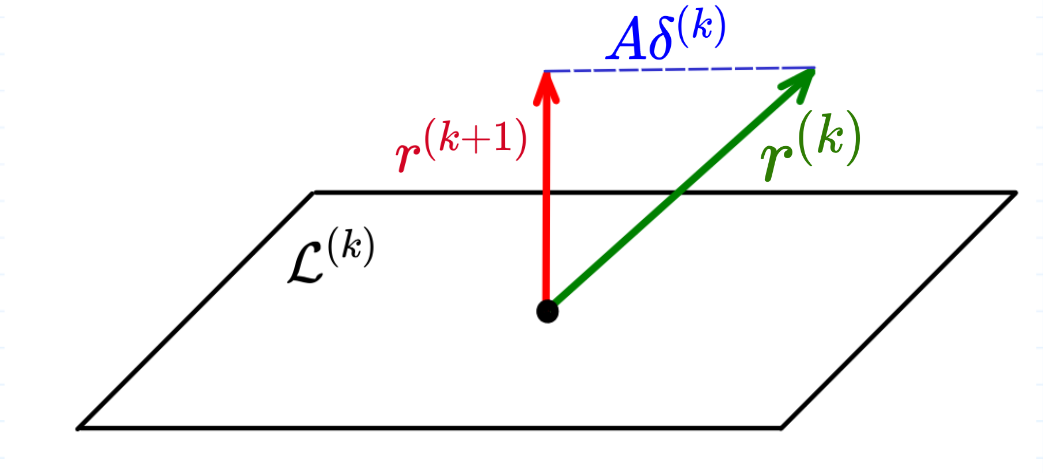

## Representación matricial

Si  $\mathcal{K}^{(k)}=\mbox{span}(V)$, es decir, es la imagen de una matriz $V$ con columnas linealmente independientes, entonces $\delta^{(k)}=Vy^{(k)}$. 
De igual forma, si  $\mathcal{L}^{(k)}=\mbox{span}(W)$ entonces íitem 2. arriba es equivalente a $$W^Tr^{(k+1)}=0.$$
Reemplazando $$r^{(k+1)}=r^{(k)}-A\delta^{(k)}$$ obtenemos 
$$ 
W^TAV y^{(k)} =W^Tr^{(k)}
$$
que da, en caso que que $H:=W^TAV$ sea no singular (lo cual hay que garantizar de alguna forma), 
$$
 y^{(k)} =(W^TAV)^{-1}W^Tr^{(k)}.
$$
Obtenemos finalmente, 
$$x^{(k+1)}=x^{(k)} + V(W^TAV)^{-1}W^Tr^{(k)}
$$
y además, 
$$r^{(k+1)}=r^{(k)}-A Vy^{(k)} $$.




Tenemos el siguiente pseudocódigo:


Hasta convergencia haga:
1. Seleccionar  subsepacios $\mathcal{K}$ y $\mathcal{L}$
2.       Seleccionar bases $V=[v_1,v_2,\dots,v_m]$ y $W=[w_1,w_2,\dots,w_m]$ para  $\mathcal{K}$ y $\mathcal{L}$
3.       Calcular residuo $r=b-Ax$
4.       Calcular $y=(W^TAV)^{-1}W^Tr$
5.       Actualizar $x=x+Vy$


El lector puede veriicar que $W^TAV$ es no singular sii ningún vector del subspacio $A\mathcal{K}$ es ortogonal al subspacio $\mathcal{L}$.

**Teorema:** Si tenemos alguna de las dos posibilidades
1. $A$ is positiva definida y $\mathcal{K}=\mathcal{L}$, o
2. $A$ es no singular y $\mathcal{L}=A\mathcal{K}$
entonces $H=W^TAV$ es no singular para cualquier bases $V$ y $W$ de  $\mathcal{K}$ y $\mathcal{L}$. 

## Teoría general

**Proposición:** Asuma que $A$ es simetrica y positiva definida con $\mathcal{K}=\mathcal{L}$. Supoga que $Ax_*=b$. Etonces un vector $\bar{x}$ es el result de un método de projección orgotonal sobre $\mathcal{K}$ con vector inicial $x_0$ sii 
$$
\bar{x} \in \arg \min E(x)
$$
donde 
$$
E(x):=\Big( (x_*-x)^TA(x_*-x) \Big)^{0.5} := ||x_*-x ||_A.
$$

**Proposición:** Asuma que $A$ es no singulary que $\mathcal{L}=A\mathcal{K}$. Supoga que $Ax_*=b$. 
Etonces un vector $\tilde{x}$ es el resultado de un método de projección (oblicua) sobre $\mathcal{K}$ y ortogonalmente a $\mathcal{L}$ con vector inicial $x_0$ sii 
$$\tilde{x} \in \arg \min R(x)
$$
donde 
$$R(x):=||b-Ax||_2.$$

## Error

## Proyecciones unidimensionales

### Descenso mas profundo

Recuerde que con $H=W^TAV$ tenemos el incremento
$$
 y =H^{-1}W^Tr.
$$
y la acutalización 
$$x=x + VH^{-1}W^Tr.$$


En este caso $V=[r]$ y $W=[r]$. En este caso $H=r^TAr$ y $y=\frac{r^Tr}{r^TAr}=\alpha$. 
Por lo que la acutalización es 
$$
x=x+\alpha r.
$$
y 
$$r=r-\alpha Ar.$$

Tenemos el suguiente algoritmo, 

**Algoritmo:**

0. Calcular $r=b-Ax$ y $p=Ar$

Hasta convergencia haga, 
1. $\alpha=r^Tr/r^Tp$
2. $x=x+\alpha r$
3. $r=r-\alpha p$
4. $p=Ar$



In [3]:
using LinearAlgebra
using Plots

In [5]:
Aaux=rand(5,5)
A=Aaux'Aaux+0.1*I
display(A)

5×5 Matrix{Float64}:
 2.04471   0.941613  2.11071  1.54617  1.31211
 0.941613  1.2097    1.2478   0.76267  1.15464
 2.11071   1.2478    2.71164  1.84833  1.65367
 1.54617   0.76267   1.84833  2.13279  1.05712
 1.31211   1.15464   1.65367  1.05712  1.45967

In [52]:
function dmp(A,x,b,M,tol)
    r=b-A*x
    p=A*r
    nr0=norm(r)
    for i=1:M
        nr2=dot(r,r)
        nr=sqrt(nr2)
        println("Norma r_",i," =",nr)
        if ( nr/nr0< tol)  # necesita garatizar un buen residuo inicial
            break
        end
        α=nr2/dot(r,p)
        x=x+α*r
        r=r-α*p
        p=A*r
    end
    return x
end

dmp (generic function with 2 methods)

In [55]:
b=fill(1,size(A)[2])
x=fill(0,size(A)[2])
x=dmp(A,x,b,2,0.001)
b-A*x

Norma r_1 =2.23606797749979
Norma r_2 =0.4281816949152737


5-element Vector{Float64}:
 0.38266098171185603
 0.274194627281239
 0.23893757336702182
 0.41324406802042335
 0.25166010823443785

**Teorema:** Suponga que $A$ es simetrica positiva definida. La norma $A$ del vector de error 
$$
e^{(k)}=x_*-x^{(k)}
$$
generado por el algorimo de descenso mas profundo satisface la reslación 
$$
||d^{(k+1)}||_A\leq \Big( \frac{\lambda_\max-\lambda_\min}{\lambda_\max+\lambda_\min}\Big) ||e^{(k)}||_A
$$
y por tanto converge para cualquier dato inicial. 

### Iteración de residuo mínimo
Asumimos que $A^T+A$ es positiva definida y selecionamos en cada itearción  $V=[r]$ y $W=[Ar]$. En este caso $H=r^TA^TAr=Ar\cdot Ar $ y $y=\frac{r^Tr}{r^TA^TAr}=\alpha$. 
Por lo que la acutalización es 
$$
x=x+\alpha r.
$$
y 
$$r=r-\alpha Ar.$$

Tenemos el suguiente algoritmo, 

**Algoritmo:**

0. Calcular $r=b-Ax$ y $p=Ar$

Hasta convergencia haga, 
1. $\alpha=r^Tr/p^Tp$
2. $x=x+\alpha r$
3. $r=r-\alpha p$
4. $p=Ar$


**Teorema:** Suponga que $A$ es simetrica positiva definida con entradas reales. Sea 
$$
\mu=\lambda_\min(A+A^T/2), \mbox{ y } \sigma=||A||_2.
$$
Entonces el vector residuo generado por la iteración de mínimo residuo cumple la relación
$$
||r^{(k+1)}||_2\leq \Big( 1- \frac{\mu^2}{\sigma^2} \Big)^\frac{1}{2} ||r^{(k)}||_2
$$
y por tanto converge para cualquier dato inicial. 

In [57]:
function mr(A,x,b,M,tol)
    r=b-A*x
    p=A*r
    nr0=norm(r)
    for i=1:M
        nr2=dot(r,r)
        nr=sqrt(nr2)
        println("Norma r_",i," =",nr)
        if ( nr/nr0< tol)  # necesita garatizar un buen residuo inicial
            break
        end
        α=nr2/dot(p,p)
        x=x+α*r
        r=r-α*p
        p=A*r
    end
    return x
end

mr (generic function with 1 method)

In [63]:
Amr = [7.0  5.0   0.0  4.0  4.0;
 5.0  9.0   5.0  1.0  1.0;
 9.0  9.0  13.0  4.0  3.0;
 8.0  0.0   3.0  4.0  1.0;
 2.0  8.0   1.0  3.0  9.0]

Norma r_1 =2.23606797749979
Norma r_2 =1.9440337507760508


5-element Vector{Float64}:
 0.38266098171185603
 0.274194627281239
 0.23893757336702182
 0.41324406802042335
 0.25166010823443785

In [66]:
bmr=fill(1,size(A)[2])
xmr=fill(0,size(A)[2])
xmr=mr(A,xmr,b,200,0.001)

Norma r_1 =2.23606797749979
Norma r_2 =1.9440337507760508
Norma r_3 =1.6901234404114762
Norma r_4 =1.4693593914683802
Norma r_5 =1.277413901439944
Norma r_6 =1.1105243845797883
Norma r_7 =0.9654196358274423
Norma r_8 =0.8392557745811843
Norma r_9 =0.7295606792978093
Norma r_10 =0.6341860151006956
Norma r_11 =0.5512665485350843
Norma r_12 =0.4791885399761554
Norma r_13 =0.4165812057205325
Norma r_14 =0.3624835593030271
Norma r_15 =0.3296682842637431
Norma r_16 =0.2869636915899511
Norma r_17 =0.24994847207628706
Norma r_18 =0.21796048686184785
Norma r_19 =0.19055239107165514
Norma r_20 =0.16797019480554812
Norma r_21 =0.16401514979774062
Norma r_22 =0.14399880739767956
Norma r_23 =0.1280919898005882
Norma r_24 =0.131144980792154
Norma r_25 =0.11550129943814447
Norma r_26 =0.10396451760673095
Norma r_27 =0.19332636246280438
Norma r_28 =0.16806245637708253
Norma r_29 =0.14609442485241214
Norma r_30 =0.1269915233916095
Norma r_31 =0.1103791284731744
Norma r_32 =0.0959313534079791
Norma r_33

5-element Vector{Float64}:
  0.49228887288586093
  0.7987385829216974
 -0.7827442334205643
  0.4018720411843917
  0.207176111701407

### Descenso mas profundo en la norma del residuo

Asumimos que $A$ es no singular y selecionamos en cada itearción  $V=[A^Tr]$ y $W=[Av=AA^Tr]$. En este caso $H=r^TAA^TAA^Tr$ y $y=\frac{r^TAA^Tr}{r^TAA^TAA^Tr}=\alpha$. 
Por lo que la acutalización es 
$$
x=x+\alpha A^Tr.
$$
y 
$$r=r-\alpha AA^Tr.$$

Tenemos el suguiente algoritmo, 

**Algoritmo:**

0. Calcular $r=b-Ax$

Hasta convergencia haga, 
1. $v=A^Tr$
2. $\alpha=||v||^2/||(Av) ||^2$
3. $x=x+\alpha r$
4. $r=r-\alpha p$


## Procesos aditivos y multiplicativos

Considere una descomposición de $\mathcal{R}^n$ en $p$ subspacios $\mbox{span}(V_i)$, $i=1,2,\dots,p$, de dimensión $n_i$ de tal forma que 
$V_i\subset \mathcal{R}^n$ y $\mathcal{R}^n=\sum_{i=1}^p \mbox{span}(V_i)$.
Tambien requerimos que $\mbox{span}(V_i)\not = \mbox{span}(V_j)$ for $i\not = j$. 

En este caso tomarmos $\mathcal{K}=\mathcal{L}=\mbox{span}(V_i)$ para $i=1,2,\dots,p$. 
Defina 
$$
A_i=V_i^TAV_i
$$
y
$$
y_i = A_i^{-1}V_i^Tr^{(k)}, i=1,2,\dots,p.
$$
Actualice 
$$
x^{(k+1)} = x^{(k)} + \sum_{i=1}^p V_iy_i=  x^{(k)} + \Big(\sum_{i=1}^p V_iA_i^{-1}V_i^T\Big)r^{(k)}.
$$

El proximo residuo es 

$$
r^{(k+1)} =b- Ax^{(k+1)}=\Big(I-\sum_{i=1}^p A V_iA_i^{-1}V_i^T\Big)r^{(k)}.
$$

Defina la proyección sobre $AV_i$ ortogonalmente a $V_i$ por 
$$
P_i= A V_iA_i^{-1}V_i^T.
$$
Entonces 
$$
r^{(k+1)}=\Big(I-\sum_{i=1}^p P_i\Big)r^{(k)}.
$$
Si se usan parametros de acelaración $\omega_i$, actualizamos $x^{(k+1)} = x^{(k)} + \sum_{i=1}^p \omega_iV_iy_i$ y obtenemos 
$$
r^{(k+1)}=\Big(I-\sum_{i=1}^p \omega_iP_i\Big)r^{(k)}.
$$

**Algoritmo:**
Para $k=0,1,\dots$, hasta convergencia, haga
1. Calcule $r=b-Ax$.
2. for i=1,2,\dots,p, haga
3. resuleva $A_iy_i=V_i^Tr$
4. fin para i
5. Actualice $x = x + \sum_{i=1}^p V_iy_i$


Alternativamente, pormode tomar $\mathcal{K}=\mbox{span}(V_i)$ y $\mathcal{L}=A\mathcal{K}$  para $i=1,2,\dots,p$. Si este es el caso, optenemos una expresión similar con proyecciones ortogonales,
$$
P_i= A V_i \Big( (AV_i)^TAV_i  \Big)^{-1} (AV_i)^T.
$$

Adicionalmente, en lugar de actulizar el residuo al final de ciclo (externo) de $i=1,2,\dots,p$, podemos actualizarlo en cada subspacio. Tendríamos el siguiente algoritmo. 

**Algoritmo:**

Para $k=0,1,\dots$, hasta convergencia, haga
1. for i=1,2,\dots,p, haga
2. Calcule residuo $b-Ax$
2. Resuelva $A_iy_i=V_i^Tr$
3. Actualice $x=x+V_i y_i
3. fin para i

# Referencias
1. Saad, Yousef. Iterative methods for sparse linear systems. Society for Industrial and Applied Mathematics, 2003.